# Introduction

This script creates a comprehensive thematic map for visualizing watershed Cr values.
The workflow is as follows:
  1. Preview: An initial quick look at the raw geospatial network data.
  2. Load Data: Ingests a shapefile, a CSV with watershed groupings, and a CSV with Cr values.
  3. Process Data: Merges these data sources, calculates the percentage difference of each
     group's Cr value from a defined reference value, and categorizes this difference.
  4. Visualize: Generates a final map where:
     - Watershed groups are colored based on their categorized Cr difference.
     - Boundaries for each watershed group are explicitly drawn.
     - The original Cr value is annotated within each group.

# 1. Library Imports and Global Configuration

This block handles the import of necessary libraries and sets up all global
configuration parameters. Centralizing these parameters makes it easy to
manage file paths and adjust analysis constants without altering the main logic.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# --- Configuration & Parameters ------------------------------------------------
# Input file paths
SHP_FILE_PATH = Path("/home/zli333/hpchome/DA/2025_EKI/sangamon/link_maps/network.shp")
GROUPING_CSV_PATH = Path("/home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/hlm_data/structure/watershed_division_by_filtered_joints.csv")
CR_VALUES_CSV_PATH = Path("/home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/out/Simulated_Experiments/local_Cr/5583000-order[6]/csv/9_post_params_mean.csv") # Assuming this file is in the same directory as the script

# Analysis parameters
WATERSHED_DEPTH = 6
CR_REF = 1.2 # Reference Cr value for difference calculation

# Categorization parameters for coloring
PERCENTAGE_THRESHOLDS = [0.1, 1, 5, 10, 20, 50, 100]

# Plotting parameters
FIGURE_SIZE = (17, 14)
ANNOTATION_FONT_SIZE = 6
LEGEND_FONT_SIZE = 'x-small'
GROUP_BOUNDARY_COLOR = 'black'
GROUP_BOUNDARY_LINEWIDTH = 0.8

# 2. Preliminary Shapefile Analysis

This block provides an initial "sanity check" of the input shapefile.
The `preview_shapefile` function loads the data, prints key metadata
(info, head, CRS), and displays a simple plot of the network geometry.
This helps confirm that the file is being read correctly before proceeding
with the main analysis.

In [2]:
def preview_shapefile(shp_path: Path):
    """Loads and provides a quick preview of the shapefile contents."""
    print("--- 1. Initial Shapefile Preview ---")
    if not shp_path.exists():
        print(f"Error: Shapefile not found at {shp_path}", file=sys.stderr)
        return # Don't exit, allow main script to handle final exit

    try:
        gdf = gpd.read_file(shp_path)
        
        print("\n--- GeoDataFrame Info ---")
        gdf.info()
        
        print("\n--- First 5 Rows ---")
        print(gdf.head())
        
        print(f"\n--- Coordinate Reference System (CRS) ---\n{gdf.crs}")

        # Generate a simple plot preview
        print("\nDisplaying simple preview map of the network...")
        fig, ax = plt.subplots(figsize=(8, 8))
        gdf.plot(ax=ax, linewidth=0.5, color='grey')
        ax.set_title("Preview of Network Shapefile Geometry")
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Could not preview shapefile due to an error: {e}", file=sys.stderr)
    print("--- End of Shapefile Preview ---\n")

# 3. Data Loading Functions

This block contains data loading utility functions. Each function is responsible
for loading a specific type of data (geospatial, grouping, Cr values)
and includes validation checks to ensure robustness. Encapsulating this logic
simplifies the main workflow and improves code reusability.

In [3]:
def load_geodata(shp_path: Path, id_col: str = 'LINKNO') -> gpd.GeoDataFrame:
    """Loads a shapefile and validates the specified ID column."""
    print(f"Reading shapefile for analysis: {shp_path}")
    if not shp_path.exists():
        print(f"Error: Shapefile not found at {shp_path}", file=sys.stderr)
        sys.exit(1)
    
    try:
        gdf = gpd.read_file(shp_path)
        if id_col not in gdf.columns:
            print(f"Error: ID column '{id_col}' not found in shapefile.", file=sys.stderr)
            sys.exit(1)
        
        gdf[id_col] = gdf[id_col].astype(int)
        print(f"Shapefile loaded. Found {len(gdf)} links.")
        return gdf
    except Exception as e:
        print(f"An error occurred while reading the shapefile: {e}", file=sys.stderr)
        sys.exit(1)

def load_grouping_data(csv_path: Path, depth: int, link_id_col: str = 'LINKNO') -> pd.DataFrame:
    """Loads watershed grouping data and extracts the relevant group ID column."""
    print(f"\nReading watershed division CSV: {csv_path}")
    if not csv_path.exists():
        print(f"Error: Grouping CSV not found at {csv_path}", file=sys.stderr)
        sys.exit(1)

    try:
        df = pd.read_csv(csv_path)
        if link_id_col not in df.columns:
            print(f"Error: Link ID column '{link_id_col}' not found in grouping CSV.", file=sys.stderr)
            sys.exit(1)
        
        group_col_name = f"subw_{depth}"
        if group_col_name not in df.columns:
            print(f"Error: Group column '{group_col_name}' not found for depth {depth}.", file=sys.stderr)
            sys.exit(1)
        
        df[link_id_col] = df[link_id_col].astype(int)
        print(f"Grouping CSV loaded. Found {len(df)} rows.")
        # Return only the necessary columns, renamed for clarity
        return df[[link_id_col, group_col_name]].rename(columns={group_col_name: 'group_id'})
    except Exception as e:
        print(f"An error occurred while reading the grouping CSV: {e}", file=sys.stderr)
        sys.exit(1)

def load_cr_values(csv_path: Path) -> pd.DataFrame:
    """Loads a single-column CSV of Cr values, assuming no header."""
    print(f"\nReading Cr values CSV: {csv_path}")
    if not csv_path.exists():
        print(f"Error: Cr values CSV not found at {csv_path}", file=sys.stderr)
        sys.exit(1)
        
    try:
        df = pd.read_csv(csv_path, header=None, names=['Cr_value'])
        df['Cr_value'] = df['Cr_value'].astype(float)
        print(f"Cr values CSV loaded. Found {len(df)} Cr values.")
        return df
    except Exception as e:
        print(f"An error occurred while reading the Cr values CSV: {e}", file=sys.stderr)
        sys.exit(1)


# 4. Data Processing and Visualization Functions

This section contains the core logic of the script. The `prepare_plot_data`
function handles all data integration and analysis steps. The `plot_annotated_map`
function is dedicated to creating the final visualization. This separation of
concerns makes the code easier to debug and modify.

In [11]:
def prepare_plot_data(gdf_network: gpd.GeoDataFrame, df_groups: pd.DataFrame, df_cr_list: pd.DataFrame, cr_ref: float, thresholds: list) -> gpd.GeoDataFrame:
    """Merges all data, calculates Cr difference, and categorizes for plotting."""
    
    # --- 1. Merge grouping data ---
    gdf_classified = gdf_network.merge(df_groups, on='LINKNO', how='left')
    gdf_to_plot = gdf_classified[gdf_classified['group_id'].notna()].copy()
    gdf_to_plot['group_id_numeric'] = gdf_to_plot['group_id'].astype(int)
    
    # --- 2. Map Cr values based on sorted group IDs ---
    unique_map_group_ids = sorted(gdf_to_plot['group_id_numeric'].unique())
    num_unique_map_groups = len(unique_map_group_ids)
    num_cr_values = len(df_cr_list)

    print(f"\nFound {num_unique_map_groups} unique group IDs in map data to be plotted.")
    if num_cr_values != num_unique_map_groups:
        print(f"Warning: Cr value count ({num_cr_values}) != unique map group ID count ({num_unique_map_groups}). "
              "Mapping will be based on the shorter of the two lists.")
    
    min_len = min(num_cr_values, num_unique_map_groups)
    mapping_df = pd.DataFrame({
        'group_id_numeric': unique_map_group_ids[:min_len],
        'Cr_value': df_cr_list['Cr_value'].iloc[:min_len]
    })
    gdf_to_plot = gdf_to_plot.merge(mapping_df, on='group_id_numeric', how='left')
    
    # --- 3. Calculate and categorize percentage difference ---
    if 'Cr_value' in gdf_to_plot.columns and gdf_to_plot['Cr_value'].notna().any() and cr_ref != 0:
        gdf_to_plot['percentage_diff'] = ((gdf_to_plot['Cr_value'] - cr_ref).abs() / cr_ref) * 100
        
        bins = [0] + thresholds + [float('inf')]
        labels = [f'≤ {thresholds[0]}%'] + \
                 [f'{thresholds[i]}% - {thresholds[i+1]}%' for i in range(len(thresholds)-1)] + \
                 [f'> {thresholds[-1]}%']
        
        gdf_to_plot['diff_category'] = pd.cut(
            gdf_to_plot['percentage_diff'],
            bins=bins, labels=labels, right=True, include_lowest=True, ordered=True
        )
        print("Successfully calculated and categorized Cr percentage difference.")
    else:
        gdf_to_plot['diff_category'] = None # Ensure column exists
        print("\nWarning: Could not calculate Cr difference. Data may be missing or Cr_ref is 0.")
        
    return gdf_to_plot

def plot_annotated_map(gdf: gpd.GeoDataFrame, config: dict):
    """Plots the final map, colored by difference category, with Cr value annotations."""
    
    if 'diff_category' not in gdf.columns or gdf['diff_category'].notna().sum() == 0:
        print("\nCannot plot map: No valid 'diff_category' data available.", file=sys.stderr)
        return

    print(f"\nPlotting {len(gdf)} links, colored by Cr % difference category...")
    fig, ax = plt.subplots(1, 1, figsize=config['figsize'])
    
    # --- Plot main map based on difference category ---
    active_categories = gdf['diff_category'].cat.categories
    cmap = plt.get_cmap('Reds', len(active_categories))
    
    gdf.plot(
        ax=ax,
        column='diff_category',
        cmap=cmap,
        legend=True,
        legend_kwds={
            'title': f'% Difference from Cr_ref ({config["cr_ref"]})',
            'loc': 'upper left', 'bbox_to_anchor': (1.02, 1),
            'fontsize': config['legend_fontsize'], 'ncol': 1
        },
        categorical=True,
        missing_kwds={"color": "lightgrey", "label": "No Data / Not Categorized"}
    )
    
    # --- Annotate with original Cr values ---
    if 'Cr_value' in gdf.columns and gdf['Cr_value'].notna().any():
        print(f"\nAnnotating actual Cr values...")
        dissolved = gdf.dissolve(by='group_id_numeric', aggfunc={'Cr_value': 'first'})
        dissolved['point'] = dissolved.geometry.representative_point()
        
        annotated_count = 0
        for _, row in dissolved.iterrows():
            if pd.notna(row['Cr_value']) and row['point']:
                ax.text(
                    row['point'].x, row['point'].y, f"{row['Cr_value']:.2e}",
                    fontsize=config['annotation_fontsize'], ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.5, ec='none')
                )
                annotated_count += 1
        print(f"Prepared {annotated_count} annotations.")

    ax.set_title(f"Network Links: Cr % Difference from Ref={config['cr_ref']} (Depth {config['depth']})")
    ax.set_axis_off()
    plt.tight_layout(rect=[0, 0, 0.80, 1])
    plt.show()

# 5. Main Execution Block

This is the script's entry point. The `main` function orchestrates the entire
workflow by calling the data loading, processing, and visualization functions
in sequence. Using `if __name__ == "__main__":` is a Python best practice that
allows the script to be both executed directly and imported into other modules
without running automatically.

--- 1. Initial Shapefile Preview ---

--- GeoDataFrame Info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 300624 entries, 0 to 300623
Data columns (total 29 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   LINKNO      300624 non-null  int64   
 1   DSLINKNO    300624 non-null  int64   
 2   USLINKNO1   300624 non-null  int64   
 3   USLINKNO2   300624 non-null  int64   
 4   DSNODEID    300624 non-null  int64   
 5   strmOrder   300624 non-null  int64   
 6   Length      300624 non-null  float64 
 7   Magnitude   300624 non-null  int64   
 8   DSContArea  300624 non-null  float64 
 9   strmDrop    300624 non-null  float64 
 10  Slope       300624 non-null  float64 
 11  StraightL   300624 non-null  float64 
 12  USContArea  300624 non-null  float64 
 13  WSNO        300624 non-null  int64   
 14  DOUTEND     300624 non-null  float64 
 15  DOUTSTART   300624 non-null  float64 
 16  DOUTMID     300624 non-null  float64 


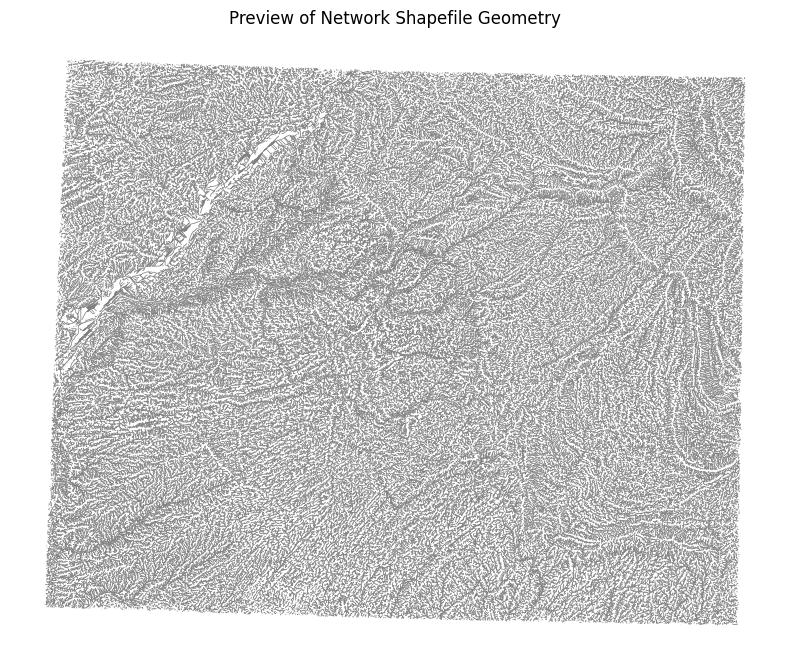

--- End of Shapefile Preview ---



In [5]:
# --- Step 0: Preview input shapefile ---
preview_shapefile(SHP_FILE_PATH)

Reading shapefile for analysis: /home/zli333/hpchome/DA/2025_EKI/sangamon/link_maps/network.shp
Shapefile loaded. Found 300624 links.

Reading watershed division CSV: /home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/hlm_data/structure/watershed_division_by_filtered_joints.csv
Grouping CSV loaded. Found 116779 rows.

Reading Cr values CSV: /home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/out/Simulated_Experiments/local_Cr/5583000-order[6]/csv/9_post_params_mean.csv
Cr values CSV loaded. Found 71 Cr values.

Found 71 unique group IDs in map data to be plotted.
Successfully calculated and categorized Cr percentage difference.

Plotting 116779 links, colored by Cr % difference category...

Annotating actual Cr values...
Prepared 71 annotations.


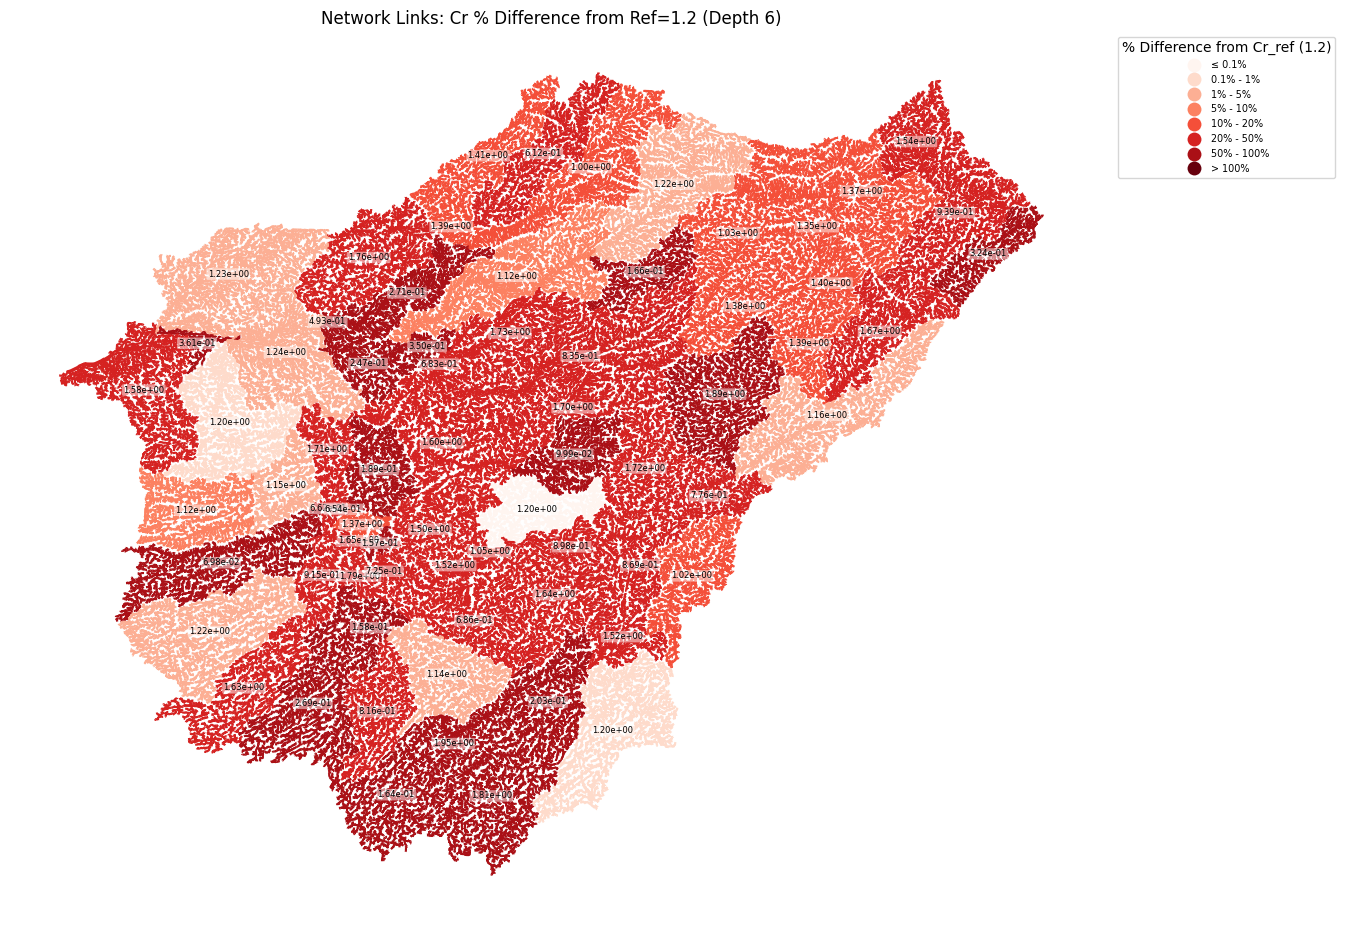

In [13]:
# --- Step 1: Load all data sources for analysis ---
gdf_network = load_geodata(SHP_FILE_PATH, id_col='LINKNO')
df_groups = load_grouping_data(GROUPING_CSV_PATH, depth=WATERSHED_DEPTH, link_id_col='LINKNO')
df_cr_list = load_cr_values(CR_VALUES_CSV_PATH)

# --- Step 2: Process and prepare data for plotting ---
gdf_to_plot = prepare_plot_data(gdf_network, df_groups, df_cr_list, CR_REF, PERCENTAGE_THRESHOLDS)

# --- Step 3: Visualize the results ---
if not gdf_to_plot.empty:
    plot_config = {
        'cr_ref': CR_REF,
        'depth': WATERSHED_DEPTH,
        'figsize': FIGURE_SIZE,
        'annotation_fontsize': ANNOTATION_FONT_SIZE,
        'legend_fontsize': LEGEND_FONT_SIZE,
    }
    plot_annotated_map(gdf_to_plot, plot_config)
else:
    print("\nFinal prepared GeoDataFrame is empty. Nothing to plot.", file=sys.stderr)

Reading shapefile for analysis: /home/zli333/hpchome/DA/2025_EKI/sangamon/link_maps/network.shp
Shapefile loaded. Found 300624 links.

Reading watershed division CSV: /home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/hlm_data/structure/watershed_division_by_filtered_joints.csv
Grouping CSV loaded. Found 116779 rows.

Reading Cr values CSV: /home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/out/Simulated_Experiments/local_Cr/5583000-order[7]/csv/9_post_params_mean.csv
Cr values CSV loaded. Found 13 Cr values.

Found 13 unique group IDs in map data to be plotted.
Successfully calculated and categorized Cr percentage difference.

Plotting 116779 links, colored by Cr % difference category...

Annotating actual Cr values...
Prepared 13 annotations.


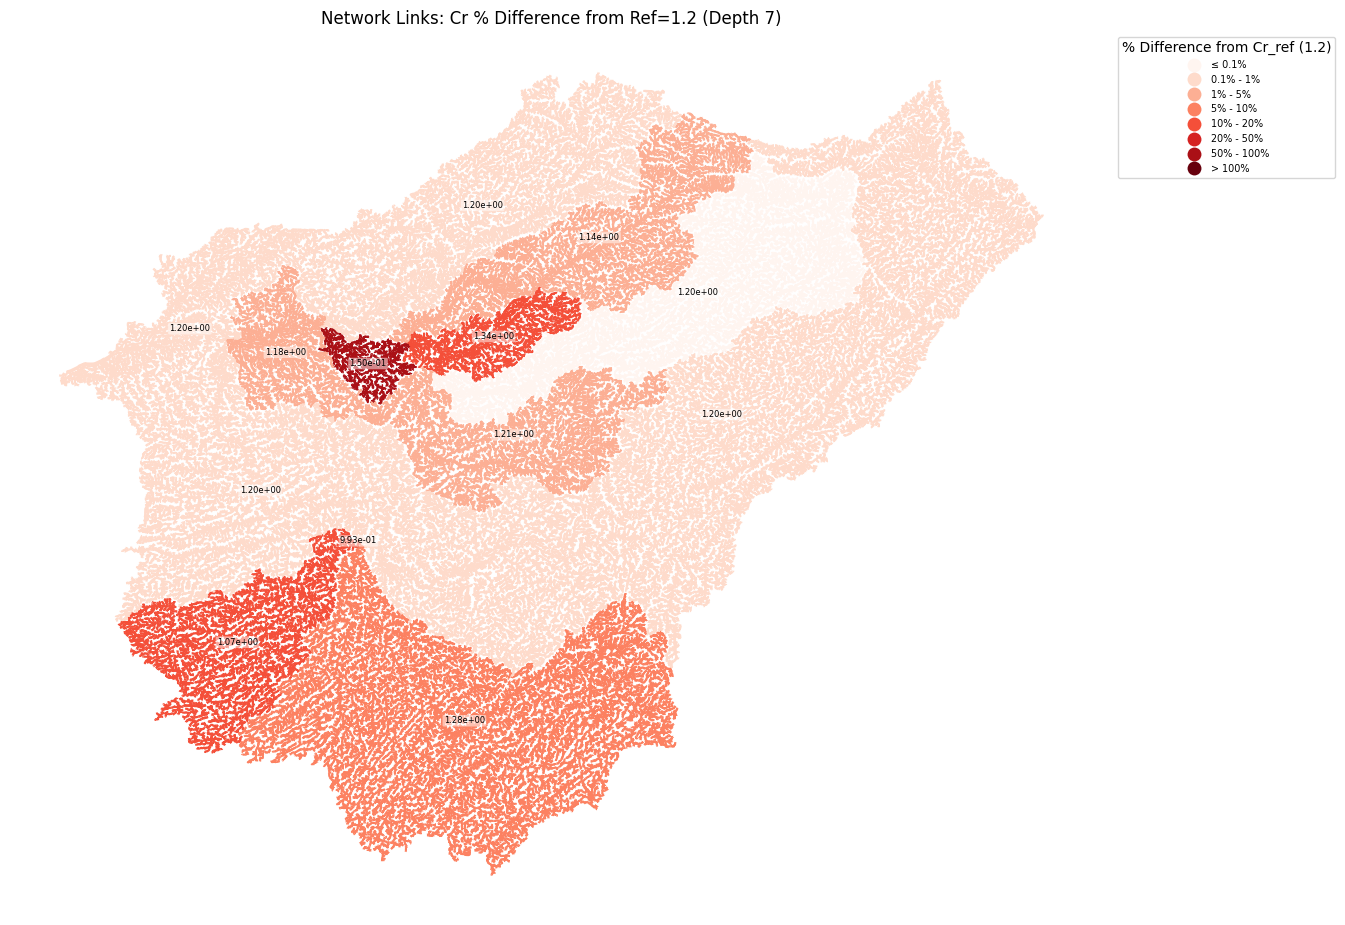

In [14]:
# --- Step 1: Load all data sources for analysis ---

CR_VALUES_CSV_PATH = Path("/home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/out/Simulated_Experiments/local_Cr/5583000-order[7]/csv/9_post_params_mean.csv")
WATERSHED_DEPTH = 7

gdf_network = load_geodata(SHP_FILE_PATH, id_col='LINKNO')
df_groups = load_grouping_data(GROUPING_CSV_PATH, depth=WATERSHED_DEPTH, link_id_col='LINKNO')
df_cr_list = load_cr_values(CR_VALUES_CSV_PATH)

# --- Step 2: Process and prepare data for plotting ---
gdf_to_plot = prepare_plot_data(gdf_network, df_groups, df_cr_list, CR_REF, PERCENTAGE_THRESHOLDS)

# --- Step 3: Visualize the results ---
if not gdf_to_plot.empty:
    plot_config = {
        'cr_ref': CR_REF,
        'depth': WATERSHED_DEPTH,
        'figsize': FIGURE_SIZE,
        'annotation_fontsize': ANNOTATION_FONT_SIZE,
        'legend_fontsize': LEGEND_FONT_SIZE,
    }
    plot_annotated_map(gdf_to_plot, plot_config)
else:
    print("\nFinal prepared GeoDataFrame is empty. Nothing to plot.", file=sys.stderr)

Reading shapefile for analysis: /home/zli333/hpchome/DA/2025_EKI/sangamon/link_maps/network.shp
Shapefile loaded. Found 300624 links.

Reading watershed division CSV: /home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/hlm_data/structure/watershed_division_by_filtered_joints.csv
Grouping CSV loaded. Found 116779 rows.

Reading Cr values CSV: /home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/out/Simulated_Experiments/local_Cr/5583000-order[8]/csv/9_post_params_mean.csv
Cr values CSV loaded. Found 3 Cr values.

Found 3 unique group IDs in map data to be plotted.
Successfully calculated and categorized Cr percentage difference.

Plotting 116779 links, colored by Cr % difference category...

Annotating actual Cr values...
Prepared 3 annotations.


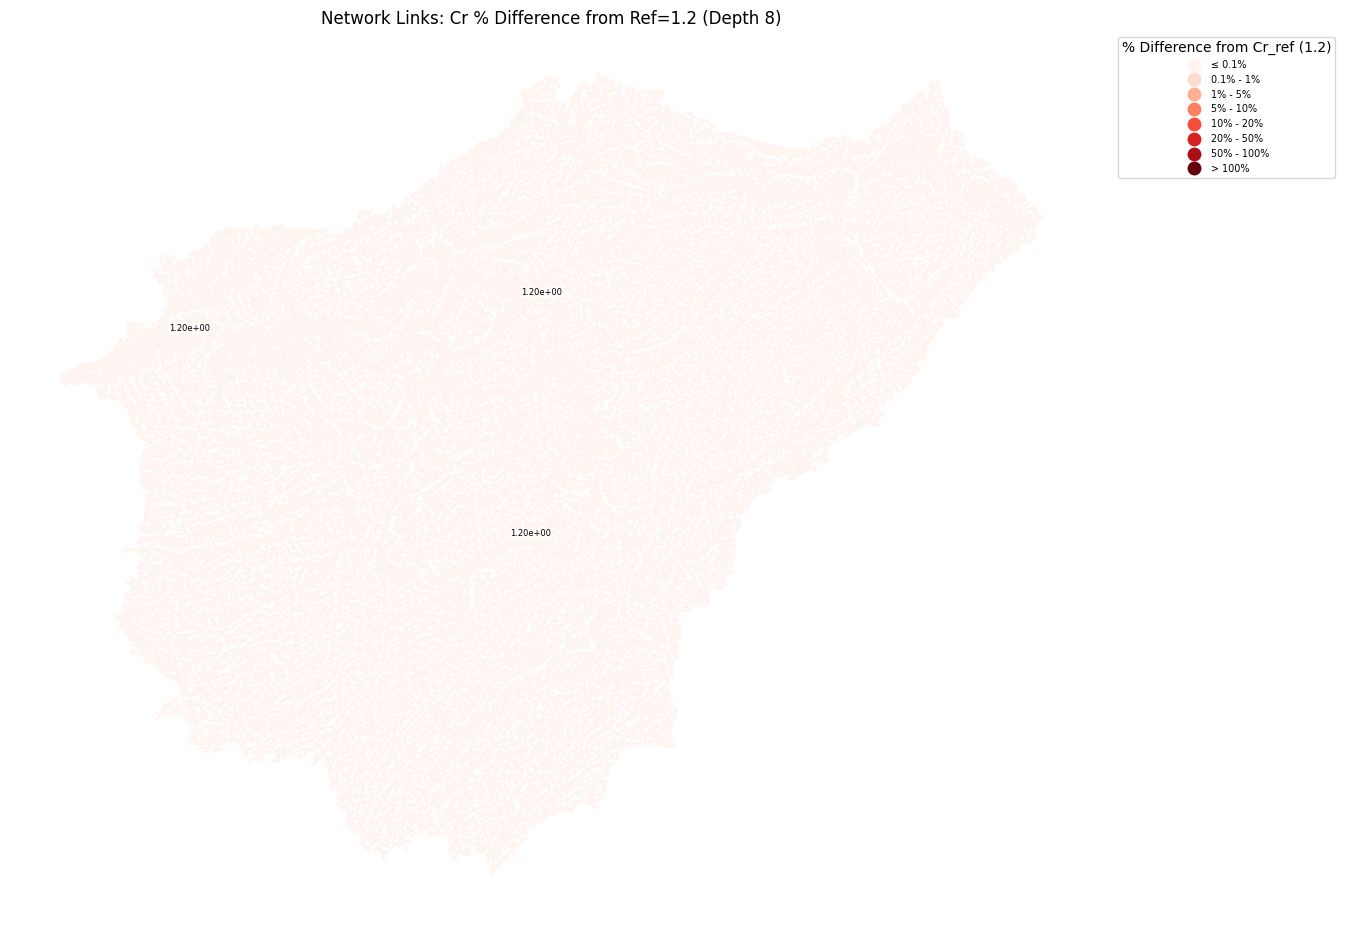

In [15]:
# --- Step 1: Load all data sources for analysis ---

CR_VALUES_CSV_PATH = Path("/home/zli333/hpchome/DA/2025_EKI/Inverse_Problem/out/Simulated_Experiments/local_Cr/5583000-order[8]/csv/9_post_params_mean.csv")
WATERSHED_DEPTH = 8

gdf_network = load_geodata(SHP_FILE_PATH, id_col='LINKNO')
df_groups = load_grouping_data(GROUPING_CSV_PATH, depth=WATERSHED_DEPTH, link_id_col='LINKNO')
df_cr_list = load_cr_values(CR_VALUES_CSV_PATH)

# --- Step 2: Process and prepare data for plotting ---
gdf_to_plot = prepare_plot_data(gdf_network, df_groups, df_cr_list, CR_REF, PERCENTAGE_THRESHOLDS)

# --- Step 3: Visualize the results ---
if not gdf_to_plot.empty:
    plot_config = {
        'cr_ref': CR_REF,
        'depth': WATERSHED_DEPTH,
        'figsize': FIGURE_SIZE,
        'annotation_fontsize': ANNOTATION_FONT_SIZE,
        'legend_fontsize': LEGEND_FONT_SIZE
    }
    plot_annotated_map(gdf_to_plot, plot_config)
else:
    print("\nFinal prepared GeoDataFrame is empty. Nothing to plot.", file=sys.stderr)